# 3. Activation Functions

Without activation functions, a neural network is just a big linear regression model.
Activation functions introduce **non-linearity**, allowing networks to learn complex patterns.
Let's explore the most common ones!

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

## 1. Why Non-Linearity?

If we stack linear layers: $y = W_2(W_1 x) = (W_2 W_1)x = W_{new}x$.
It collapses into a single linear layer!

We need: $y = W_2(\sigma(W_1 x))$, where $\sigma$ is non-linear.

## 2. Sigmoid

$\sigma(x) = \frac{1}{1 + e^{-x}}$

- **Range**: (0, 1)
- **Pros**: Good for probabilities.
- **Cons**: 
    - **Vanishing Gradient**: Gradients are very small for large/small inputs.
    - **Not Zero-Centered**: Outputs are always positive.

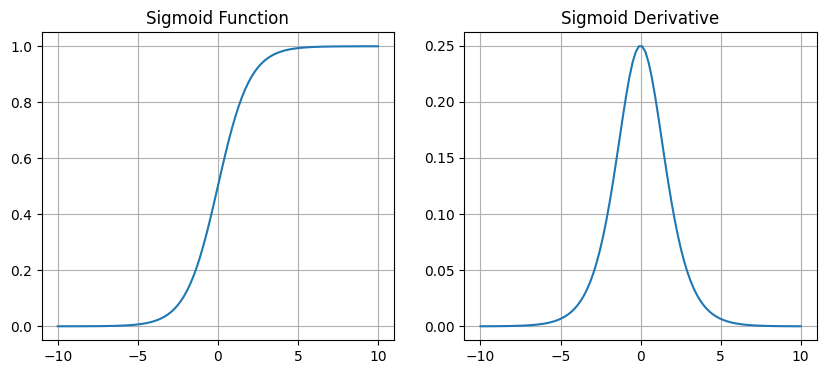

In [2]:
x = torch.linspace(-10, 10, 100, requires_grad=True)
y = torch.sigmoid(x)
y.sum().backward() # Compute gradients

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x.detach(), y.detach())
plt.title("Sigmoid Function")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x.detach(), x.grad)
plt.title("Sigmoid Derivative")
plt.grid(True)
plt.show()

## 3. Tanh (Hyperbolic Tangent)

$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$

- **Range**: (-1, 1)
- **Pros**: Zero-centered (better for optimization).
- **Cons**: Still suffers from vanishing gradients.

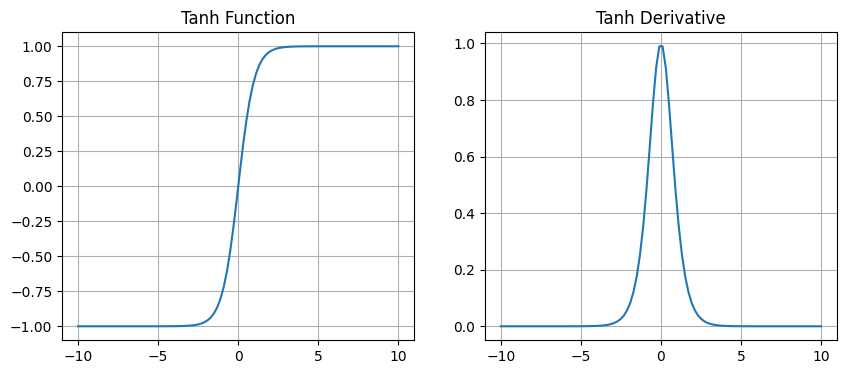

In [3]:
x.grad.zero_()
y = torch.tanh(x)
y.sum().backward()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x.detach(), y.detach())
plt.title("Tanh Function")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x.detach(), x.grad)
plt.title("Tanh Derivative")
plt.grid(True)
plt.show()

## 4. ReLU (Rectified Linear Unit)

$ReLU(x) = \max(0, x)$

- **Range**: [0, inf)
- **Pros**: 
    - Computationally efficient.
    - No vanishing gradient for positive inputs.
- **Cons**: 
    - **Dying ReLU**: If input < 0, gradient is 0. Neuron can "die" and never recover.

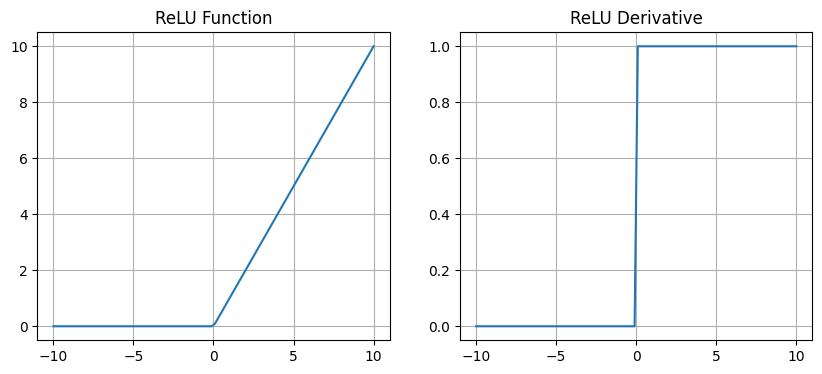

In [4]:
x.grad.zero_()
y = torch.relu(x)
y.sum().backward()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x.detach(), y.detach())
plt.title("ReLU Function")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x.detach(), x.grad)
plt.title("ReLU Derivative")
plt.grid(True)
plt.show()

## 5. Leaky ReLU

$LeakyReLU(x) = \max(0.01x, x)$

- **Pros**: Fixes Dying ReLU by allowing a small gradient for negative inputs.

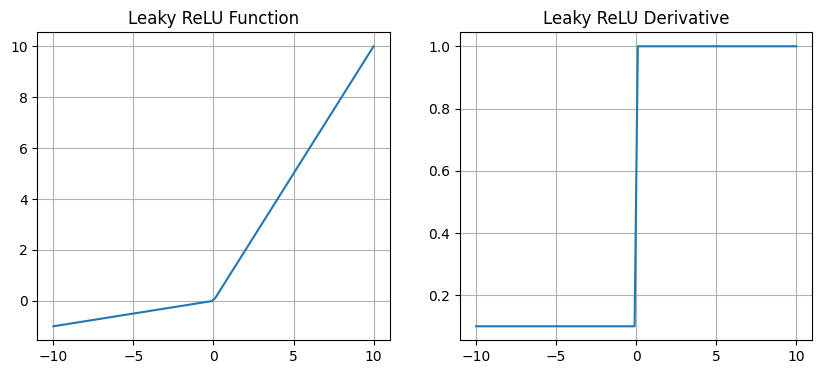

In [5]:
x.grad.zero_()
y = torch.nn.functional.leaky_relu(x, negative_slope=0.1)
y.sum().backward()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x.detach(), y.detach())
plt.title("Leaky ReLU Function")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x.detach(), x.grad)
plt.title("Leaky ReLU Derivative")
plt.grid(True)
plt.show()

## 6. Conclusion

- Use **ReLU** as your default for hidden layers.
- Use **Sigmoid** only for the output of binary classification.
- Use **Softmax** (next tutorial) for multi-class classification.